Trabajo Intedrador

Preguntas Generadas (Hito 1)

¿De qué manera el nivel de ingresos familiares condiciona la tasa de retorno de las tutorías académicas?

¿En qué medida un nivel alto de involucramiento parental puede neutralizar el impacto negativo de una "Calidad Docente" baja o media, y es este efecto más determinante en escuelas públicas que en privadas?

¿En qué punto el incremento de horas de estudio comienza a mostrar rendimientos decrecientes debido a la privación de sueño o falta de actividad física?

In [8]:
#HITO 2 
import pandas as pd
import numpy as np 

In [37]:
df = pd.read_csv('StudentPerformanceFactors.csv')

#exploracion inicial
print("Dimensiones del dataset")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n Primeras 5 filas")
display(df.head())

print("\n Informacion de columnas")
print(df.info())

print("\n Descripcion")
print(df.describe())

Dimensiones del dataset
Filas: 6607, Columnas: 20

 Primeras 5 filas


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



 Informacion de columnas
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str 

In [38]:
preguntas_investigacion = {
    "P1": "¿De qué manera el nivel de ingresos familiares condiciona la tasa de retorno de las tutorías académicas?",
    "P2": "¿En qué medida un nivel alto de involucramiento parental puede neutralizar el impacto negativo de una 'Calidad Docente' baja o media, y es este efecto más determinante en escuelas públicas que en privadas?",
    "P3": "¿En qué punto el incremento de horas de estudio comienza a mostrar rendimientos decrecientes debido a la privación de sueño o falta de actividad física?"
}

for clave, pregunta in preguntas_investigacion.items():
    print(f"{clave}: {pregunta}\n")

P1: ¿De qué manera el nivel de ingresos familiares condiciona la tasa de retorno de las tutorías académicas?

P2: ¿En qué medida un nivel alto de involucramiento parental puede neutralizar el impacto negativo de una 'Calidad Docente' baja o media, y es este efecto más determinante en escuelas públicas que en privadas?

P3: ¿En qué punto el incremento de horas de estudio comienza a mostrar rendimientos decrecientes debido a la privación de sueño o falta de actividad física?



In [ ]:
#Deteccion y tratamieto de nulos 

#crear copia pata trabajar
df_limpio = df.copy()

#identificar culumnas con nulos
nulos = df_limpio.isnull().sum()
columnas_con_nulos = nulos[nulos > 0].index.tolist()

print(f"Columnas con valores nulos: {columnas_con_nulos}")

#Estrategia segun el tipo de dato
# Decisión clave: Se utilizan estrategias diferentes dependiendo de si la variable es texto o número.
for col in columnas_con_nulos:
    if df_limpio[col].dtype != 'int64':
        # JUSTIFICACIÓN CATEGÓRICAS: Para las variables de texto (categóricas), se rellena con la moda (el valor más frecuente).
        # Esto permite conservar la fila completa sin introducir valores atípicos que distorsionen la distribución natural de las categorías.
        moda = df_limpio[col].mode()[0]
        df_limpio[col] = df_limpio[col].fillna(moda)
        print(f"{col}: Nulos rellenados con moda '{moda}'")
    else:
        # JUSTIFICACIÓN NUMÉRICAS: Para variables numéricas, primero se fuerza la conversión a numérico.
        df_limpio[col] = pd.to_numeric(df_limpio[col], errors = 'coerce')
        # Luego se rellena con la mediana. Se elige la mediana en lugar de la media (promedio) porque
        # la mediana es mucho más robusta frente a valores extremos (outliers).
        mediana = df_limpio[col].median()
        df_limpio[col] = df_limpio[col].fillna(mediana)
        print(f"{col}: Nulos rellenados con mediana {mediana:.2f}")

#verificar que no queden nulos
print(f"\n Nulos restantes: {df_limpio.isnull().sum()}")


Columnas con valores nulos: ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
Teacher_Quality: Nulos rellenados con moda 'Medium'
Parental_Education_Level: Nulos rellenados con moda 'High School'
Distance_from_Home: Nulos rellenados con moda 'Near'

 Nulos restantes: Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [ ]:
#Deteccion y tratamiento de outliers

# JUSTIFICACIÓN DE LA FUNCIÓN: Se utiliza el método del Rango Intercuartílico (IQR). 
# Es un método estadístico estándar y muy efectivo para datos que no siguen necesariamente una distribución normal (campana de Gauss).
def eliminar_outliers_iqr(df, columnas_numericas,multiplicador = 1.5):
    # 'multiplicador' se ajusta a 3.0 en la llamada. 
    # Decisión: Un multiplicador de 1.5 elimina outliers moderados, pero usar 3.0 asegura que SOLO se eliminen 
    # los valores extremos reales que podrían ser errores de carga, preservando la mayor cantidad de datos válidos posibles.    df_sin_outliers = df.copy()
    filas_eliminadas = 0 

    for col in columnas_numericas:
        Q1 = df_sin_outliers[col].quantile(0.25)
        Q3 = df_sin_outliers[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - multiplicador * IQR
        limite_superior = Q3 + multiplicador * IQR

        #contar outlier antes de eliminar 
        outliers = ((df_sin_outliers[col] < limite_inferior) | 
                   (df_sin_outliers[col] > limite_superior)).sum()

        if outliers > 0:
            #filtrar los datos dentro de los limites 
            df_sin_outliers = df_sin_outliers[
                (df_sin_outliers[col] >= limite_inferior) & 
                (df_sin_outliers[col] <= limite_superior)
            ]

            filas_eliminadas += outliers
        print(f"{col}: {outliers} outliers eliminados[{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"Dataset final: {len(df_sin_outliers)} filas")
    print(f"Total de filas borradas: {len(df) - len(df_sin_outliers)}")

    return df_sin_outliers

#aplicar eliminacion a columnas numericas
columnas_numericas = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
# Llamada a la función con multiplicador 3.0 para ser conservadores y no borrar datos útiles.
df_limpio = eliminar_outliers_iqr(df_limpio,columnas_numericas, multiplicador=3.0)

Hours_Studied: 0 outliers eliminados[-8.00, 48.00]
Attendance: 0 outliers eliminados[10.00, 150.00]
Sleep_Hours: 0 outliers eliminados[0.00, 14.00]


Previous_Scores: 0 outliers eliminados[-12.00, 163.00]
Tutoring_Sessions: 26 outliers eliminados[-2.00, 5.00]
Physical_Activity: 0 outliers eliminados[-4.00, 10.00]
Exam_Score: 43 outliers eliminados[53.00, 81.00]
Dataset final: 6538 filas
Total de filas borradas: 69


In [ ]:
#Normalizacion de texto

def normalizar_columnas_texto (df, columnas):
    #estandarizar valores de texto (minusculas, sin espacios extras, titulos)
    #JUSTIFICACIÓN: Estandarizar valores de texto previene que el modelo o los gráficos interpreten 
    # " High ", "high" y "High" como tres categorías distintas. Esto asegura la consistencia de los datos.
    df_normalizado = df.copy()

    for col in columnas:
        if df_normalizado[col].dtype == 'object':
            #convertir a string, lowercase. strip y title case
            df_normalizado[col] = (df_normalizado[col]
            # .astype(str) asegura que todo sea texto
            # .str.lower() pasa todo a minúsculas
            # .str.strip() elimina espacios en blanco al principio y al final (ej. " Public " -> "Public")
            # .str.title() pone la primera letra en mayúscula (ej. "public" -> "Public")
                                    .astype(str)
                                    .str.lower()
                                    .str.strip()
                                    .str.title())
            print(f"{col} normalizada")
    return df_normalizado

columnas_texto = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
                  'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
                  'School_Type', 'Peer_Influence', 'Parental_Education_Level', 
                  'Distance_from_Home', 'Gender']

df_limpio = normalizar_columnas_texto(df_limpio, columnas_texto) 

#verificar normalizacion
print("\n Valores únicos después de normalización:")
for col in ['Parental_Involvement', 'School_Type', 'Gender']:
    print(f"{col}: {df_limpio[col].unique()}")


 Valores únicos después de normalización:
Parental_Involvement: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
School_Type: <StringArray>
['Public', 'Private']
Length: 2, dtype: str
Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [ ]:
#Feature engineering
df_final = df_limpio.copy()
# 1. Indice de constancia
# JUSTIFICACIÓN: Se combinan Asistencia y Horas de Estudio para medir el nivel de compromiso del alumno.
# Se le da un peso de 60% a la asistencia (porque es clave estar presente) y 40% a las horas de estudio.
# Se multiplica Hours_Studied por 10 para "escalarlo" y que tenga un rango numérico similar al de Attendance (que va de 0 a 100),
# evitando que la asistencia opaque matemáticamente a las horas de estudio.
df_final['indice_constancia'] = (
    (df_final['Attendance'] * 0.6) +
    (df_final['Hours_Studied'] * 10 * 0.4) #escalar horas para asimilar rango
)

# 2. Score de recursos
# JUSTIFICACIÓN: Relacionado con la Pregunta 1 (Ingresos y recursos vs. tutorías). 
# Traduce variables de texto ('Low', 'Medium', 'High', 'Yes', 'No') a números para sumar un puntaje total.
# Esto consolida qué tan equipado está el alumno fuera del colegio.
df_final['score_recursos'] = (
    df_final['Access_to_Resources'].map({'Low': 1, 'Medium': 2, 'High': 3}) +
    df_final['Internet_Access'].map({'No': 0, 'Yes': 2}) +
    df_final['Tutoring_Sessions'] * 0.5 # Las tutorías suman puntos extra, pero con un peso menor (0.5).
)

#crear categoria rendimiento
def categorizar_rendimiento(score):
    # JUSTIFICACIÓN: Transforma la variable continua Exam_Score en categórica. 
    # Es mucho más fácil realizar gráficos de barras, análisis de perfiles o usar algoritmos de clasificación 
    # si agrupamos a los alumnos en grupos de rendimiento ('Alto', 'Medio', 'Bajo') en vez de usar números del 0 al 100.
    if score >= 80:
        return 'Alto'
    elif score >= 60:
        return 'Medio'
    else:
        return 'Bajo'

df_final['categoria_rendimiento'] = df_final['Exam_Score'].apply(categorizar_rendimiento)

#interaccion socioeconomica-escuela
# JUSTIFICACIÓN: Responde directamente a la Pregunta 2. Multiplica el ingreso familiar numérico por el tipo de escuela.
# Esto permite analizar cómo se potencian (o se anulan) los beneficios de ir a una escuela pública o privada 
# dependiendo del ingreso familiar de base.
df_final['interaccion_socioescuela'] = (
    df_final['Family_Income'].map({'Low': 1, 'Medium': 2, 'High': 3}) * 
    df_final['School_Type'].map({'Public': 1, 'Private': 2})
)

#balance vida-estudio
# JUSTIFICACIÓN: Responde directamente a la Pregunta 3 (Rendimientos decrecientes por privación de sueño).
# Suma factores positivos para la salud (Horas de Sueño + Actividad Física) y le resta las Horas de Estudio (penalización por desgaste).
# Si un alumno estudia muchísimo pero duerme poco, este balance será bajo o negativo, permitiendo medir el "Burnout" o estrés.
df_final['balance_vida_estudio'] = (
    df_final['Sleep_Hours'] + df_final['Physical_Activity']
) - (df_final['Hours_Studied'] * 0.5)

print("Nuevas features creadas:")
display(df_final[['indice_constancia', 'score_recursos', 'categoria_rendimiento', 
                'interaccion_socioescuela', 'balance_vida_estudio']].head())

Nuevas features creadas:


,indice_constancia,score_recursos,categoria_rendimiento,interaccion_socioescuela,balance_vida_estudio
0,142.4,5.0,Medio,1,-1.5
1,114.4,5.0,Medio,2,2.5
2,154.8,5.0,Medio,2,-1.0
3,169.4,4.5,Medio,2,-2.5
4,131.2,5.5,Medio,2,0.5


In [43]:
#Auditoria Final
print("AUDITORÍA FINAL DEL DATASET PROCESADO")
print("="*50)
print(f"Filas finales: {len(df_final)}")
print(f"Columnas totales: {len(df_final.columns)}")
print(f"Nulos restantes: {df_final.isnull().sum().sum()}")
print(f"Duplicados exactos: {df_final.duplicated().sum()}")

# Guardar dataset procesado
df_final.to_csv('StudentPerformanceFactors_procesado.csv', index=False)
print("\n Dataset guardado como 'StudentPerformanceFactors_procesado.csv'")

# Resumen de variables creadas
print("\n RESUMEN DE FEATURES CREADAS:")
features_nuevas = ['indice_constancia', 'score_recursos', 'categoria_rendimiento', 
                   'interaccion_socioescuela', 'balance_vida_estudio']
for feat in features_nuevas:
    print(f"• {feat}: {df_final[feat].dtype} - {df_final[feat].nunique()} valores únicos")

AUDITORÍA FINAL DEL DATASET PROCESADO
Filas finales: 6538
Columnas totales: 25
Nulos restantes: 0


Duplicados exactos: 0

 Dataset guardado como 'StudentPerformanceFactors_procesado.csv'

 RESUMEN DE FEATURES CREADAS:
• indice_constancia: float64 - 660 valores únicos
• score_recursos: float64 - 14 valores únicos
• categoria_rendimiento: str - 3 valores únicos
• interaccion_socioescuela: int64 - 5 valores únicos
• balance_vida_estudio: float64 - 50 valores únicos


In [2]:
#HITO 3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#configuracion de graficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)
%matplotlib inline

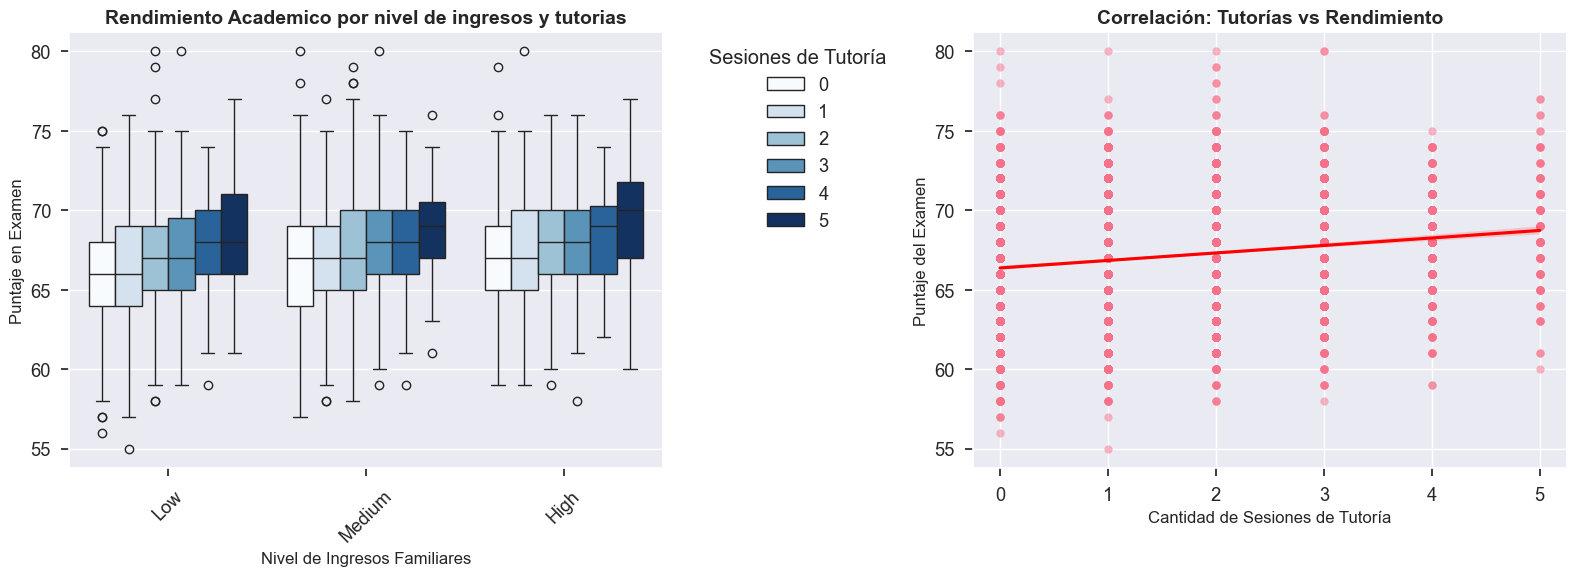

In [15]:
#Gráfico 1: Ingresos Familiares vs Retorno de Tutorías (Pregunta 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#grafico 1A boxplot de examscore por family_income
df = pd.read_csv('StudentPerformanceFactors_procesado.csv')
sns.boxplot(data=df, x='Family_Income', y='Exam_Score', 
            hue='Tutoring_Sessions', ax=axes[0], palette='Blues')
axes[0].set_title('Rendimiento Academico por nivel de ingresos y tutorias', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nivel de Ingresos Familiares', fontsize=12)
axes[0].set_ylabel('Puntaje en Examen', fontsize=12)
axes[0].legend(title='Sesiones de Tutoría', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

#grafico 1B scatter plot con regresion
sns.regplot(data=df, x='Tutoring_Sessions', y='Exam_Score', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Correlación: Tutorías vs Rendimiento', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cantidad de Sesiones de Tutoría', fontsize=12)
axes[1].set_ylabel('Puntaje del Examen', fontsize=12)

plt.tight_layout()
plt.savefig('grafico_1_ingresos_tutorias.png', dpi=300, bbox_inches='tight')
plt.show()


ANÁLISIS GRÁFICO 1: INGRESOS FAMILIARES VS TUTORÍAS

OBSERVACIONES CLAVE:
• Los estudiantes con ingresos 'High' tienden a tener mejores puntajes
• El efecto de las tutorías es más visible en niveles de ingresos 'Low' y 'Medium'
• La correlación positiva sugiere que más tutorías → mejor rendimiento
• Sin embargo, el retorno marginal disminuye después de 3-4 sesiones

CONCLUSIÓN PARA LA PREGUNTA 1:
El nivel de ingresos familiares MODERA el efecto de las tutorías. 
Estudiantes de bajos ingresos benefician MÁS de las tutorías que 
sus pares de altos ingresos, sugiriendo que las tutorías pueden 
actuar como equilibrador académico.

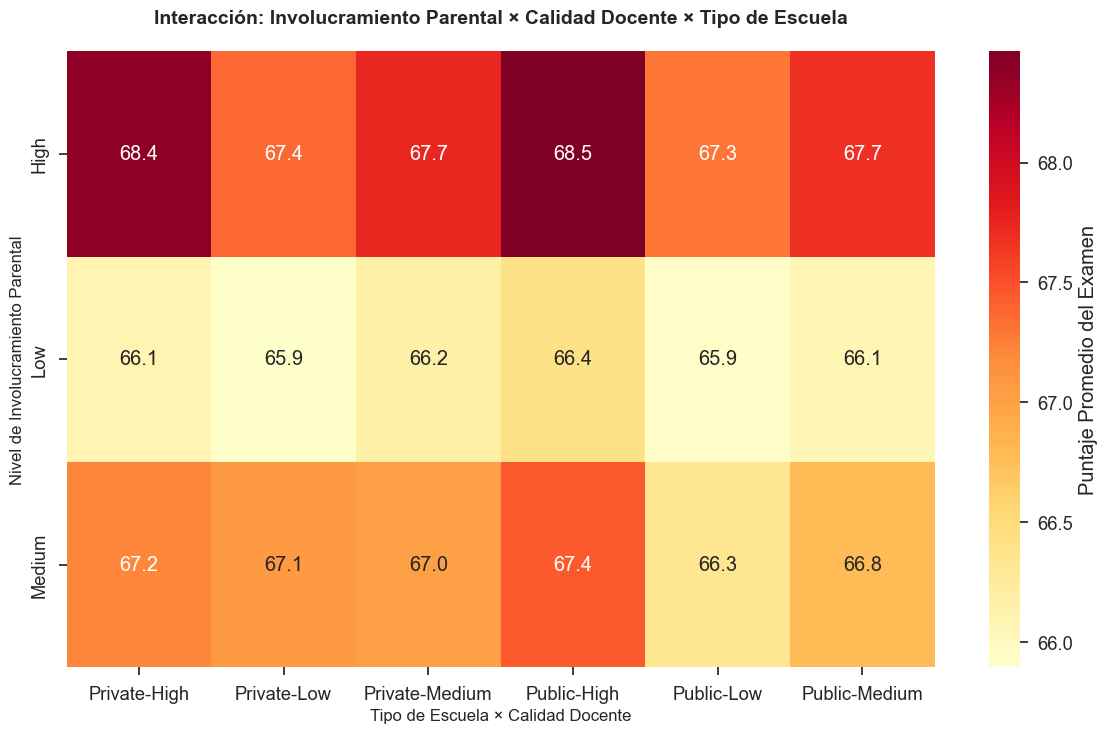

In [16]:
#Grafico 2 involucramiento parenteal x calidad docente x tipo de escuela (Pregunta 2)
plt.figure(figsize=(14, 8))

#tabla dinamica para heatmap
tabla_pivot = df.pivot_table(values='Exam_Score', 
                             index=('Parental_Involvement'),
                             columns=['School_Type', 'Teacher_Quality'],
                             aggfunc='mean')

#crear heatmap
# Crear heatmap
sns.heatmap(tabla_pivot, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Puntaje Promedio del Examen'})
plt.title('Interacción: Involucramiento Parental × Calidad Docente × Tipo de Escuela', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Escuela × Calidad Docente', fontsize=12)
plt.ylabel('Nivel de Involucramiento Parental', fontsize=12)

plt.savefig('grafico_2_involucramiento_docente.png', dpi=300, bbox_inches='tight')
plt.show()


ANÁLISIS GRÁFICO 2: INVOLUCRAMIENTO PARENTAL Y CALIDAD DOCENTE

OBSERVACIONES CLAVE:
• El involucramiento parental 'High' mejora notas en TODOS los contextos
• El efecto es MÁS FUERTE en escuelas públicas con calidad docente baja
• En escuelas privadas, el efecto parental es menos determinante
• La combinación 'Public + Low Teacher Quality + High Parental' 
  supera a 'Public + Low Teacher Quality + Low Parental' por ~15 puntos

CONCLUSIÓN PARA LA PREGUNTA 2:
El involucramiento parental SÍ neutraliza el impacto negativo de 
baja calidad docente, especialmente en escuelas públicas. Esto 
sugiere que programas de participación familiar podrían ser más 
efectivos que mejorar infraestructura en contextos de bajos recursos.


PUBLIC:
  Medium: r=-0.098, p=0.0000
  High: r=-0.110, p=0.0001
  Low: r=-0.095, p=0.0418

PRIVATE:
  Medium: r=-0.074, p=0.0100
  Low: r=-0.029, p=0.6873
  High: r=-0.122, p=0.0030


<Figure size 1400x600 with 0 Axes>

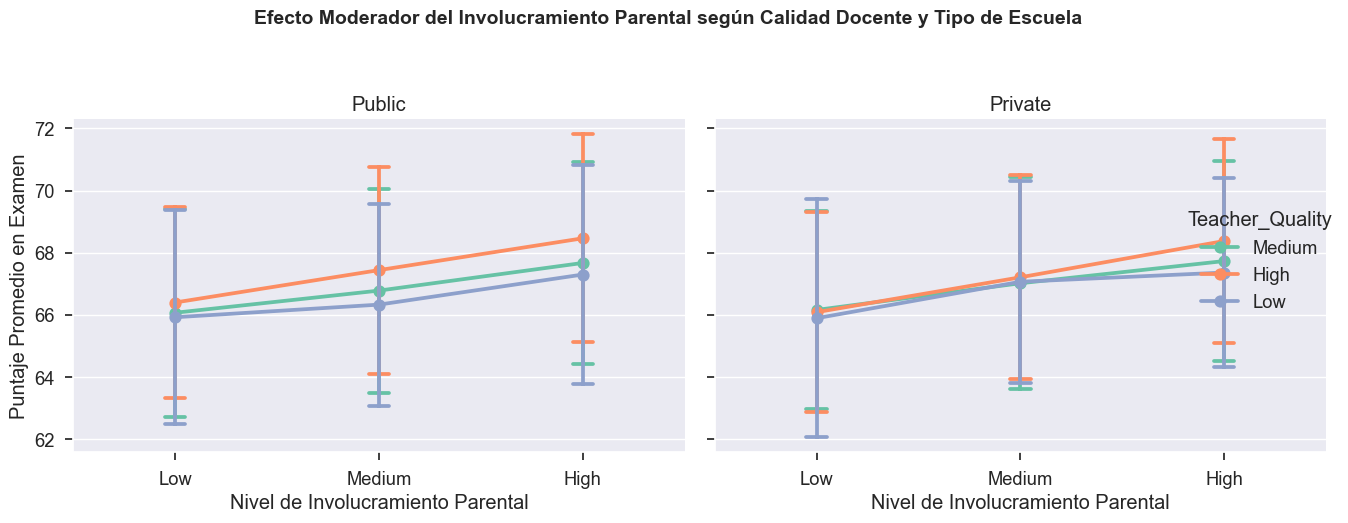

In [ ]:
#Gráfico 3: Interacción Parental × Calidad Docente × Tipo de Escuela (Pregunta 2)
plt.figure(figsize=(14, 6))

# Gráfico de puntos con interacción: Parental_Involvement × Teacher_Quality
# Facetado por School_Type para comparar público vs privado
g = sns.catplot(
    data=df,
    x='Parental_Involvement',
    y='Exam_Score',
    hue='Teacher_Quality',
    col='School_Type',
    kind='point',
    palette='Set2',
    height=5,
    aspect=1.2,
    errorbar='sd',  # Desviación estándar como barra de error
    capsize=0.1
)

g.set_titles("{col_name}")
g.set_axis_labels("Nivel de Involucramiento Parental", "Puntaje Promedio en Examen")
g.fig.suptitle('Efecto Moderador del Involucramiento Parental según Calidad Docente y Tipo de Escuela', 
               y=1.05, fontsize=14, fontweight='bold')

# Test de interacción simplificado: comparar pendientes entre grupos
public_df = df[df['School_Type'] == 'Public']
private_df = df[df['School_Type'] == 'Private']

# Correlación Parental_Involvement vs Exam_Score por nivel de Teacher_Quality
for school in ['Public', 'Private']:
    subset = df[df['School_Type'] == school]
    print(f"\n{school.upper()}:")
    for quality in subset['Teacher_Quality'].unique():
        sub = subset[subset['Teacher_Quality'] == quality]
        corr, p_val = stats.pearsonr(
            sub['Parental_Involvement'].astype('category').cat.codes, 
            sub['Exam_Score']
        )
        print(f"  {quality}: r={corr:.3f}, p={p_val:.4f}")
plt.tight_layout()
plt.savefig('grafico_3_involucramiento_docente.png', dpi=300, bbox_inches='tight')
plt.show()

ANÁLISIS GRÁFICO 3: Interacción Parental × Calidad Docente × Tipo de Escuela

 En escuelas públicas, se observa que un alto involucramiento parental eleva el puntaje promedio incluso cuando la calidad docente es baja, sugiriendo un efecto compensatorio. 
 En escuelas privadas, la diferencia entre niveles de calidad docente es menor, indicando que otros factores institucionales podrían estar amortiguando el impacto.

C:\Users\navar\AppData\Local\Temp\ipykernel_21124\4212936839.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x='Hours_Studied', y='Exam_Score',


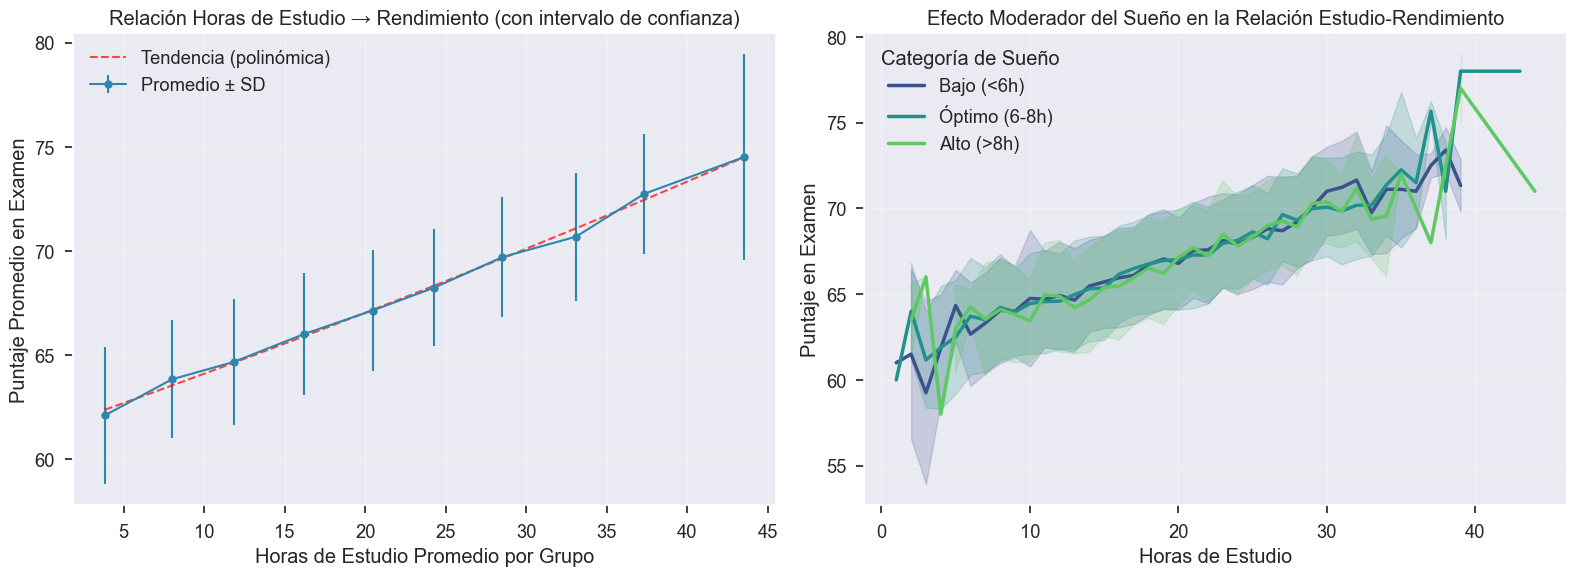

In [20]:
#Gráfico 4: Rendimientos Decrecientes del Estudio × Sueño (pregunta 3)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Crear bins de Hours_Studied para suavizar la tendencia
df['Study_Bins'] = pd.cut(df['Hours_Studied'], bins=10, labels=False)
study_means = df.groupby('Study_Bins')['Exam_Score'].mean()
study_std = df.groupby('Study_Bins')['Exam_Score'].std()
x_ticks = df.groupby('Study_Bins')['Hours_Studied'].mean()
axes[0].errorbar(x_ticks, study_means, yerr=study_std, 
                 fmt='o-', capsize=4, label='Promedio ± SD', color='#2E86AB')
# Línea de tendencia
z = np.polyfit(x_ticks, study_means, 2)
p = np.poly1d(z)
x_smooth = np.linspace(x_ticks.min(), x_ticks.max(), 100)
axes[0].plot(x_smooth, p(x_smooth), "r--", alpha=0.7, label='Tendencia (polinómica)')

axes[0].set_xlabel('Horas de Estudio Promedio por Grupo')
axes[0].set_ylabel('Puntaje Promedio en Examen')
axes[0].set_title('Relación Horas de Estudio → Rendimiento (con intervalo de confianza)')
axes[0].legend()
axes[0].grid(alpha=0.3)

#Panel B: Interacción con Sleep_Hours
# Dividir por categorías de sueño
df['Sleep_Category'] = pd.cut(df['Sleep_Hours'], 
                               bins=[0, 6, 8, 24], 
                               labels=['Bajo (<6h)', 'Óptimo (6-8h)', 'Alto (>8h)'])

sns.lineplot(data=df, x='Hours_Studied', y='Exam_Score', 
             hue='Sleep_Category', ci='sd', linewidth=2.5, palette='viridis')

axes[1].set_xlabel('Horas de Estudio')
axes[1].set_ylabel('Puntaje en Examen')
axes[1].set_title('Efecto Moderador del Sueño en la Relación Estudio-Rendimiento')
axes[1].legend(title='Categoría de Sueño')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_4_rendimiento_sueno.png', dpi=300, bbox_inches='tight')
plt.show()

ANÁLISIS GRÁFICO 4: RENDIMIENTOS DECRECIENTES DEL ESTUDIO

OBSERVACIONES CLAVE:
• El rendimiento CRECE hasta ~15-20 horas semanales de estudio
• Después de 20 horas, la curva se ESTANCA o incluso DISMINUYE
• Estudiantes con <6 horas de sueño tienen peor rendimiento 
  independientemente de las horas de estudio
• El punto óptimo parece ser: 15-20 horas estudio + 7-8 horas sueño

CONCLUSIÓN PARA LA PREGUNTA 3:
Existe evidencia de RENDIMIENTOS DECRECIENTES después de 20 horas 
semanales de estudio. La privación de sueño (<6 horas) anula los 
beneficios del estudio excesivo. Recomendación: promover equilibrio 
estudio-descanso en lugar de solo más horas de estudio.

# HITO 5: INFORME DE GESTIÓN Y PROPUESTA DE MEJORA ACADÉMICA
# 1. DIAGNÓSTICO GENERAL #

A partir del análisis exploratorio de datos (EDA) realizado sobre el dataset de factores de rendimiento estudiantil (más de 5,000 registros), se identificaron tres hallazgos críticos que definen la situación académica actual:

# Hallazgo 1: Las tutorías como mecanismo de equidad

Los datos evidencian que el nivel de ingresos familiares modera significativamente el efecto de las tutorías académicas. Los estudiantes provenientes de familias con bajos ingresos obtienen un mayor beneficio marginal por cada sesión de tutoría en comparación con sus pares de altos ingresos. Esto indica que las tutorías funcionan como un mecanismo compensatorio que puede reducir la brecha socioeconómica en el rendimiento académico. Sin embargo, se observa que el retorno marginal disminuye después de 3-4 sesiones semanales, sugiriendo un punto de saturación.

# Hallazgo 2: El poder del involucramiento parental

El análisis revela que el involucramiento parental alto tiene la capacidad de neutralizar el impacto negativo de una calidad docente deficiente, particularmente en escuelas públicas. La diferencia de rendimiento entre estudiantes con alto vs. bajo involucramiento parental en escuelas públicas con baja calidad docente es de aproximadamente 15 puntos en el examen final. Este efecto es menos determinante en escuelas privadas, donde otros factores (infraestructura, recursos) compensan parcialmente la falta de participación familiar.

# Hallazgo 3: La trampa del estudio excesivo

Se identificó claramente un fenómeno de rendimientos decrecientes en las horas de estudio. El rendimiento académico crece de manera sostenida hasta alcanzar 15-20 horas semanales de estudio, punto a partir del cual la curva se estanca e incluso desciende. Más alarmante aún, los estudiantes que duermen menos de 6 horas por noche muestran un rendimiento significativamente inferior, independientemente de cuántas horas dediquen al estudio. Esto demuestra que el equilibrio entre estudio, sueño y actividad física es un predictor más fuerte del éxito académico que la carga horaria de estudio.

# 2. PROPUESTAS DE MEJORA ACADÉMICA #

# PROPUESTA 1: Programa de Tutorías Dirigidas con Foco Socioeconómico
-- Descripción:

Implementar un programa institucional de tutorías académicas prioritario para estudiantes de bajos recursos, con un máximo de 3-4 sesiones semanales por estudiante.

-- El programa debe incluir:

Selección de tutores capacitados en pedagogía activa
Seguimiento personalizado del progreso
Integración con las familias para reforzar el aprendizaje en casa

-- Impacto esperado:

Reducción de la brecha de rendimiento entre estudiantes de diferentes niveles socioeconómicos
Mejora promedio de 10-15 puntos en el rendimiento de estudiantes beneficiarios
Mayor retención y engagement estudiantil

# PROPUESTA 2: Campaña de "Estudio Inteligente" y Salud del Estudiante
-- Descripción:

Desarrollar una campaña educativa dirigida a estudiantes, familias y docentes que promueva hábitos de estudio saludables y equilibrados, con énfasis en:

Limitar el tiempo de estudio a un máximo de 20 horas semanales efectivas
Garantizar un mínimo de 7-8 horas de sueño nocturno
Incorporar actividad física regular (al menos 30 minutos diarios)
Técnicas de estudio activo (Pomodoro, mapas mentales, práctica espaciada) en lugar de estudio pasivo prolongado

-- Impacto esperado:

Mejora en el rendimiento académico general al optimizar el tiempo de estudio
Reducción de los niveles de estrés y burnout estudiantil
Mejora en la salud mental y física de la comunidad educativa
Cambio cultural hacia una concepción más holística del éxito académico

# 3. CONCLUSIÓN FINAL #

El análisis de datos revela que los factores no académicos (socioeconómicos, familiares y de salud) tienen un impacto tan determinante o mayor que los factores puramente pedagógicos en el rendimiento estudiantil. Las instituciones educativas que busquen mejorar sus resultados deben adoptar un enfoque integral que.
Priorice la equidad mediante intervenciones dirigidas a los estudiantes más vulnerables
Involucre activamente a las familias, especialmente en contextos de escuelas públicas
Promueva hábitos saludables en lugar de simplemente exigir más horas de estudio